In [1]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt

/Users/riskyduha/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [74]:
df = pd.read_csv(
    "dataset/financial_news.csv",
    encoding="latin1",
    header=None,
    names=["label", "sentence"]
)

df["sentence"] = df["sentence"].fillna("").astype(str).str.strip()
df["sentence"] = df["sentence"].str.replace(r"\s+", " ", regex=True)
df["label"] = df["label"].astype(str).str.strip().str.lower()

valid_labels = ["negative", "neutral", "positive"]
df = df[df["label"].isin(valid_labels)].drop_duplicates().reset_index(drop=True)

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

df["label_id"] = df["label"].map(label2id)

In [76]:
df.head()

,label,sentence,label_id
0,neutral,"According to Gran , the company has no plans t...",1
1,neutral,Technopolis plans to develop in stages an area...,1
2,negative,The international electronic industry company ...,0
3,positive,With the new production plant the company woul...,2
4,positive,According to the company 's updated strategy f...,2


In [77]:
df.label.value_counts()

label
neutral     2873
positive    1363
negative     604
Name: count, dtype: int64

In [78]:
df.shape

(4840, 3)

## Split train, validation, test

In [79]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (3872, 3)
Validation: (484, 3)
Test: (484, 3)


## Hugging Face Dataset

In [80]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'sentence', 'label_id'],
        num_rows: 3872
    })
    validation: Dataset({
        features: ['label', 'sentence', 'label_id'],
        num_rows: 484
    })
    test: Dataset({
        features: ['label', 'sentence', 'label_id'],
        num_rows: 484
    })
})


## Tokenization

In [81]:
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label_id", "labels")

keep_cols = ["input_ids", "attention_mask", "labels"]
remove_cols = [c for c in tokenized_dataset["train"].column_names if c not in keep_cols]
tokenized_dataset = tokenized_dataset.remove_columns(remove_cols)

tokenized_dataset.set_format("torch")

print(tokenized_dataset)

Map: 100%|██████████| 484/484 [00:00<00:00, 29288.90 examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3872
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 484
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 484
    })
})


## Load model

In [82]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

Using device: mps


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 59803.87it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Metrik evaluasi

In [83]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Training arguments

In [84]:
training_args = TrainingArguments(
    output_dir="./finbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

## Buat Trainer dan training

In [85]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.552980,0.327593,0.871901,0.879147,0.871901,0.873154
2,0.215218,0.322744,0.884298,0.884000,0.884298,0.883993
3,0.106470,0.377794,0.888430,0.890225,0.888430,0.888797


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNor

TrainOutput(global_step=726, training_loss=0.29155602730995367, metrics={'train_runtime': 674.7933, 'train_samples_per_second': 17.214, 'train_steps_per_second': 1.076, 'total_flos': 764081365082112.0, 'train_loss': 0.29155602730995367, 'epoch': 3.0})

## Evaluasi validation dan test

In [88]:
def compute_metrics_manual(pred_output):
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )
    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# validation
val_pred = trainer.predict(tokenized_dataset["validation"])
val_results = compute_metrics_manual(val_pred)

# test
test_pred = trainer.predict(tokenized_dataset["test"])
test_results = compute_metrics_manual(test_pred)

print("Validation Results:", val_results)
print("Test Results:", test_results)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Validation Results: {'accuracy': 0.8884297520661157, 'precision': 0.8902245417185431, 'recall': 0.8884297520661157, 'f1': 0.888796814530601}
Test Results: {'accuracy': 0.878099173553719, 'precision': 0.8808615350586153, 'recall': 0.878099173553719, 'f1': 0.8788316810423004}


## Classification report

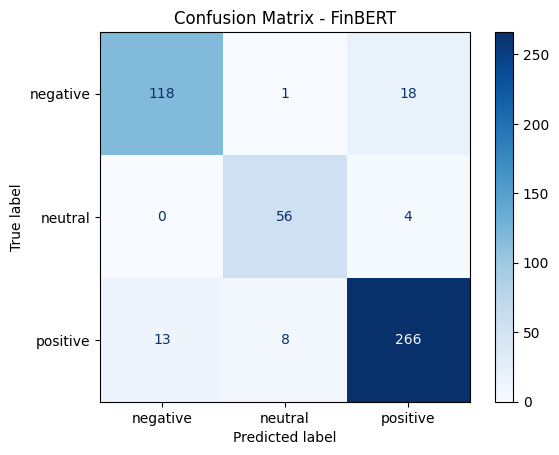

In [89]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - FinBERT")
plt.show()

In [90]:
trainer.save_model("./best_finbert_model")
tokenizer.save_pretrained("./best_finbert_model")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


('./best_finbert_model/tokenizer_config.json',
 './best_finbert_model/tokenizer.json')

## Simpan hasil prediksi test untuk error analysis

In [91]:
test_result_df = test_df.reset_index(drop=True).copy()
test_result_df["y_true"] = y_true
test_result_df["y_pred"] = y_pred
test_result_df["true_label"] = test_result_df["y_true"].map(id2label)
test_result_df["pred_label"] = test_result_df["y_pred"].map(id2label)

test_result_df.to_csv("test_predictions.csv", index=False)
print(test_result_df.head())

      label                                           sentence  label_id  \
0  positive  Loss after taxes amounted to EUR 1.2 mn compar...         2   
1   neutral  Elcoteq has a global network of After Market S...         1   
2   neutral  Marubeni has participated in GHG - Green House...         1   
3  positive  Finnish construction group Lemminkainen Oyj HE...         2   
4  negative  Outokumpu 's steel mill in Tornio , in Finland...         0   

   y_true  y_pred true_label pred_label  
0       0       0   negative   negative  
1       0       2   negative   positive  
2       0       0   negative   negative  
3       0       0   negative   negative  
4       1       1    neutral    neutral  


In [92]:
errors = test_result_df[test_result_df["y_true"] != test_result_df["y_pred"]]
print(errors[["sentence", "true_label", "pred_label"]].head(20))
print("Jumlah error:", len(errors))

                                              sentence true_label pred_label
1    Elcoteq has a global network of After Market S...   negative   positive
6    The podcast , sees Harple provide the low-down...   negative   positive
8    23 April 2010 - Finnish construction and engin...   negative   positive
23   Pearl Plaza LLC , the joint venture of SRV and...   positive   negative
32   A maximum of 20 employees , who work in Kartta...   negative    neutral
34   The company will release its 2010 results on 1...   positive   negative
61   TeliaSonera 's underlying results however incl...    neutral   positive
76   Raute is listed on the Nordic exchange in Hels...   negative   positive
80   It will focus on improving its profitability n...   positive    neutral
89   In China , Finnish Kone that provides elevator...   positive   negative
114  According to the company , staff will be laid ...   positive    neutral
128  The bank VTB24 provides mortgage loans to buy ...   positive   negative

## Prediksi sentence baru dengan model hasil fine-tuning

In [93]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model_path = "./best_finbert_model"

inference_tokenizer = AutoTokenizer.from_pretrained(model_path)
inference_model = AutoModelForSequenceClassification.from_pretrained(model_path)

inference_model = inference_model.to(device)
inference_model.eval()

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def predict_sentiment(text):
    inputs = inference_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = inference_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)[0]
    pred_id = torch.argmax(probs).item()

    return {
        "sentence": text,
        "label": id2label[pred_id],
        "negative": float(probs[0].cpu()),
        "neutral": float(probs[1].cpu()),
        "positive": float(probs[2].cpu())
    }

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8857.67it/s]


In [100]:
new_sentences = [
    # Positive
    "The company posted record earnings for the second consecutive quarter.",
    "Revenue grew significantly after strong demand in the European market.",
    "Operating profit improved due to lower production costs.",
    "The firm announced a successful expansion into new international markets.",
    "Net sales increased by 18 percent compared to last year.",

    # Neutral
    "The company released its quarterly financial statement on Monday.",
    "Sales remained unchanged compared to the previous quarter.",
    "The board announced the appointment of a new chief executive officer.",
    "The firm will publish its annual report next month.",
    "The company maintained its full-year guidance.",

    # Negative
    "The company reported a sharp decline in operating profit.",
    "Net losses widened because of rising raw material costs.",
    "Revenue fell significantly due to weak consumer demand.",
    "The firm announced layoffs after disappointing financial results.",
    "Production was suspended following a major supply chain disruption."
]

for text in new_sentences:
    result = predict_sentiment(text)
    print(result)

{'sentence': 'The company posted record earnings for the second consecutive quarter.', 'label': 'positive', 'negative': 0.0310469139367342, 'neutral': 0.0031345041934400797, 'positive': 0.9658185243606567}
{'sentence': 'Revenue grew significantly after strong demand in the European market.', 'label': 'positive', 'negative': 0.006448657251894474, 'neutral': 0.0017477894434705377, 'positive': 0.9918035268783569}
{'sentence': 'Operating profit improved due to lower production costs.', 'label': 'positive', 'negative': 0.04057071730494499, 'neutral': 0.0023595003876835108, 'positive': 0.9570697546005249}
{'sentence': 'The firm announced a successful expansion into new international markets.', 'label': 'positive', 'negative': 0.006215101573616266, 'neutral': 0.0015686568804085255, 'positive': 0.9922162294387817}
{'sentence': 'Net sales increased by 18 percent compared to last year.', 'label': 'positive', 'negative': 0.004125111736357212, 'neutral': 0.00218118610791862, 'positive': 0.99369364

In [101]:
def predict_sentiments(texts):
    inputs = inference_tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = inference_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred_ids = torch.argmax(probs, dim=1)

    results = []
    for i, text in enumerate(texts):
        results.append({
            "sentence": text,
            "label": id2label[pred_ids[i].item()],
            "negative": float(probs[i][0].cpu()),
            "neutral": float(probs[i][1].cpu()),
            "positive": float(probs[i][2].cpu())
        })

    return pd.DataFrame(results)